In [ ]:
""""
Project Title

Implementing and Optimizing Variational Autoencoders (VAEs) for Anomaly Detection in High-Dimensional Time Series
"""""

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

In [3]:

# -----------------------------
# FIX SEEDS
# -----------------------------
np.random.seed(42)
tf.random.set_seed(42)

# -----------------------------
# CONFIGURATION
# -----------------------------
NUM_SAMPLES = 2000
TIME_STEPS = 30
NUM_FEATURES = 10
ANOMALY_RATIO = 0.06

# -----------------------------
# GENERATE NORMAL DATA
# -----------------------------
def generate_normal_data():
    data = []
    for _ in range(NUM_SAMPLES):
        t = np.linspace(0, 2*np.pi, TIME_STEPS)
        base = np.sin(t)
        sample = []
        for f in range(NUM_FEATURES):
            noise = np.random.normal(0,0.05,TIME_STEPS)
            signal = base*(1+f*0.05) + noise
            sample.append(signal)
        data.append(np.array(sample).T)
    return np.array(data)

# -----------------------------
# INJECT ANOMALIES
# -----------------------------
def inject_anomalies(data):
    labels = np.zeros(len(data))
    n_anom = int(len(data)*ANOMALY_RATIO)
    idxs = np.random.choice(len(data), n_anom, replace=False)

    for i in idxs:
        t = np.random.choice(["spike","drift","noise"])
        if t=="spike":
            data[i,10:15,:] += np.random.uniform(2,3)
        elif t=="drift":
            drift = np.linspace(0,1.5,TIME_STEPS)
            data[i] += drift[:,None]
        else:
            data[i] += np.random.normal(0,0.5,data[i].shape)
        labels[i]=1
    return data, labels

# -----------------------------
# DATASET
# -----------------------------
X = generate_normal_data()
X, y = inject_anomalies(X)

X_normal = X[y==0]

In [4]:

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_normal.reshape(-1,NUM_FEATURES))
X_train = X_train.reshape(X_normal.shape[0],TIME_STEPS*NUM_FEATURES)

X_test = scaler.transform(X.reshape(-1,NUM_FEATURES))
X_test = X_test.reshape(X.shape[0],TIME_STEPS*NUM_FEATURES)

# -----------------------------
# SAMPLING LAYER
# -----------------------------
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5*z_log_var)*eps

# -----------------------------
# VAE MODEL
# -----------------------------
class VAE(models.Model):
    def __init__(self,input_dim,latent_dim):
        super(VAE,self).__init__()
        self.e1 = layers.Dense(128,activation="relu")
        self.e2 = layers.Dense(64,activation="relu")
        self.z_mean = layers.Dense(latent_dim)
        self.z_log = layers.Dense(latent_dim)
        self.samp = Sampling()
        self.d1 = layers.Dense(64,activation="relu")
        self.d2 = layers.Dense(128,activation="relu")
        self.out = layers.Dense(input_dim)

    def call(self,x,return_latent=False):
        h = self.e1(x)
        h = self.e2(h)
        zm = self.z_mean(h)
        zv = self.z_log(h)
        z = self.samp((zm,zv))
        h = self.d1(z)
        h = self.d2(h)
        recon = self.out(h)

        kl = -0.5*tf.reduce_mean(1+zv-tf.square(zm)-tf.exp(zv))
        self.add_loss(kl)

        if return_latent:
            return recon, zm, zv
        return recon


In [5]:

# -----------------------------
# HYPERPARAMETER TUNING
# -----------------------------
latent_dims = [8,16,32]
results = []

for ld in latent_dims:
    print(f"\nTraining latent_dim = {ld}")
    vae = VAE(X_train.shape[1],ld)
    vae.compile(optimizer="adam",loss="mse")
    vae.fit(X_train,X_train,
            epochs=30,
            batch_size=32,
            verbose=0)

    recon, zm, zv = vae(X_test,return_latent=True)

    rec_err = np.mean((X_test-recon)**2,axis=1)
    kl = -0.5*np.sum(1+zv-np.square(zm)-np.exp(zv),axis=1)
    score = rec_err + kl

    thresh = np.percentile(score,95)
    preds = (score>thresh).astype(int)

    auc = roc_auc_score(y,score)
    f1 = f1_score(y,preds)

    results.append([ld,auc,f1])



Training latent_dim = 8

Training latent_dim = 16

Training latent_dim = 32


In [6]:

# RESULTS TABLE
# -----------------------------
df = pd.DataFrame(results,columns=["Latent_Dim","ROC_AUC","F1_Score"])
print("\nHyperparameter Tuning Results")
print(df)

best_ld = df.sort_values("ROC_AUC",ascending=False).iloc[0]["Latent_Dim"]
print("\nBest Latent Dimension:",best_ld)



Hyperparameter Tuning Results
   Latent_Dim  ROC_AUC  F1_Score
0           8      1.0  0.909091
1          16      1.0  0.909091
2          32      1.0  0.909091

Best Latent Dimension: 8.0


In [7]:
# -----------------------------
# TRAIN FINAL MODEL
# -----------------------------
vae = VAE(X_train.shape[1],int(best_ld))
vae.compile(optimizer="adam",loss="mse")
vae.fit(X_train,X_train,epochs=30,batch_size=32)

recon, zm, zv = vae(X_test,return_latent=True)
score = np.mean((X_test-recon)**2,axis=1) + \
        -0.5*np.sum(1+zv-np.square(zm)-np.exp(zv),axis=1)

thresh = np.percentile(score,95)
preds = (score>thresh).astype(int)

print("\nFinal Classification Report")
print(classification_report(y,preds))

print("Final ROC-AUC:",roc_auc_score(y,score))
print("Final F1:",f1_score(y,preds))


Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2034
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0200
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0132
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0052
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013
Epoch 9/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011
Epoch 10/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010
Epoch 11/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.7689e-04
Epoch 12/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.1064e-04
Epoch 13/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.6075e-04
Epoch 14/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.1429e-04
Epoch 15/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6849e-04

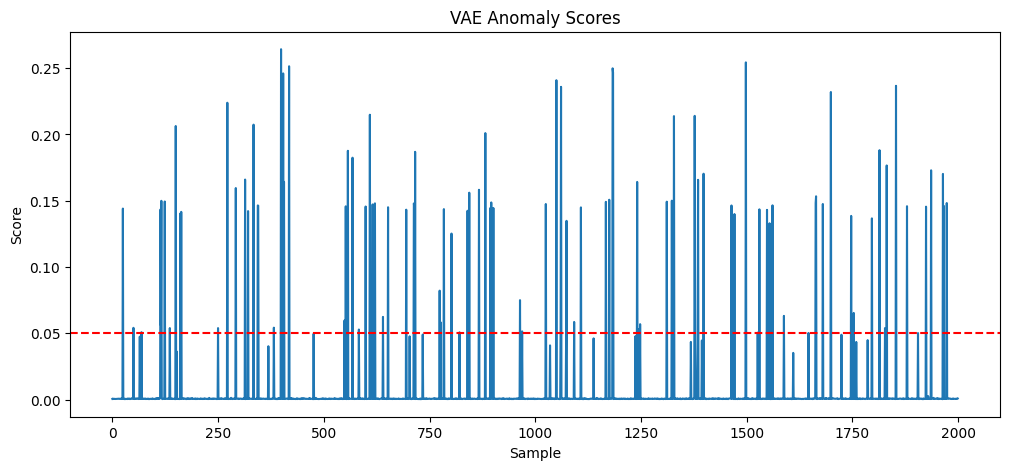

In [8]:

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(score)
plt.axhline(thresh,color="red",linestyle="--")
plt.title("VAE Anomaly Scores")
plt.xlabel("Sample")
plt.ylabel("Score")
plt.show()